In [1]:
import pandas as pd

In [2]:

ai_model_patents = 'data/ai_model_predictions_2020_2023_patents.csv'    # ai patents
genai_dimensions = 'data/genai_dimension.csv'



In [3]:
import matplotlib.pyplot as plt
import matplotlib.cbook as cbook

import numpy as np

In [34]:
patent_pd = pd.read_csv('data/ai_model_predictions_2020_2023_patents.csv', parse_dates=['pub_dt'])
model_pd = pd.read_csv('data/genai_dimension.csv', nrows= 99999999)


/var/folders/9n/krg0xmnd6ksf1sg2mvbjfyg40000gn/T/ipykernel_21097/1555133794.py:1: DtypeWarning: Columns (0: doc_id) have mixed types. Specify dtype option on import or set low_memory=False.
  patent_pd = pd.read_csv('data/ai_model_predictions_2020_2023_patents.csv', parse_dates=['pub_dt'])


In [35]:
print(patent_pd.head(10))

     doc_id  flag_patent     pub_dt   appl_id  predict50_any_ai  \
0  10524402            1 2020-01-07  15665025                 1   
1  10524403            1 2020-01-07  15794349                 0   
2  10524404            1 2020-01-07  15487306                 1   
3  10524405            1 2020-01-07  15598081                 0   
4  10524406            1 2020-01-07  15299629                 1   
5  10524407            1 2020-01-07  15639794                 1   
6  10524408            1 2020-01-07  16034186                 0   
7  10524409            1 2020-01-07  15583684                 1   
8  10524410            1 2020-01-07  15678215                 0   
9  10524411            1 2020-01-07  15870097                 0   

   predict86_any_ai  predict93_any_ai  predict50_ml  predict86_ml  \
0                 1                 1             0             0   
1                 0                 0             0             0   
2                 1                 1             0    

In [70]:
import matplotlib.pyplot as plt
model_pd['Release Date'] = pd.to_datetime(model_pd['Release Date'])

filter_ml = patent_pd[patent_pd['ai_score_ml'] > .7]
filter_nlp = patent_pd[patent_pd['ai_score_nlp'] > .7]

ml_per_date = filter_ml.groupby(pd.Grouper(key='pub_dt', freq='ME')).size()
nlp_per_date = filter_nlp.groupby(pd.Grouper(key='pub_dt', freq='ME')).size()
print(ml_per_date)

pub_dt
2020-01-31    2653
2020-02-29    2420
2020-03-31    2905
2020-04-30    3117
2020-05-31    2621
2020-06-30    3094
2020-07-31    2977
2020-08-31    2636
2020-09-30    2989
2020-10-31    3337
2020-11-30    2939
2020-12-31    3433
2021-01-31    2790
2021-02-28    2857
2021-03-31    3682
2021-04-30    3433
2021-05-31    3262
2021-06-30    3536
2021-07-31    3571
2021-08-31    3537
2021-09-30    3546
2021-10-31    3130
2021-11-30    3530
2021-12-31    3824
2022-01-31    3031
2022-02-28    3240
2022-03-31    4409
2022-04-30    3318
2022-05-31    3846
2022-06-30    4078
2022-07-31    3153
2022-08-31    3965
2022-09-30    4078
2022-10-31    3918
2022-11-30    4201
2022-12-31    4507
2023-01-31    4186
2023-02-28    3879
2023-03-31    4445
2023-04-30    3590
2023-05-31    4202
2023-06-30    4789
2023-07-31    3499
2023-08-31    4599
2023-09-30    3932
2023-10-31    4772
2023-11-30    4730
2023-12-31    3948
Freq: ME, dtype: int64


In [59]:
from datetime import datetime

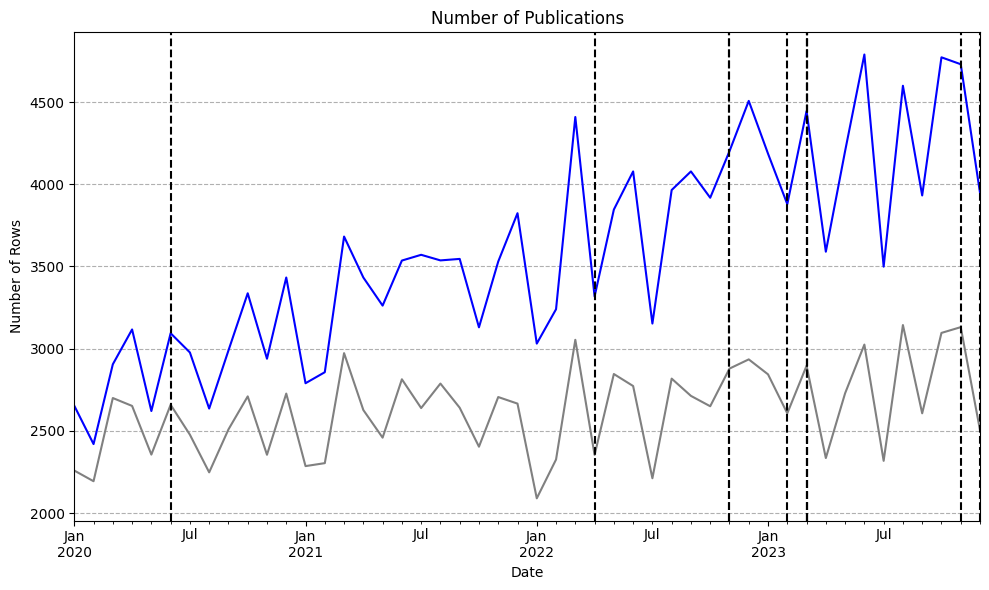

In [72]:
plt.figure(figsize=(10, 6))
ml_per_date.plot(kind='line', color='blue')
nlp_per_date.plot(kind='line', color='gray')

mask = (model_pd['Release Date'] >= '2020-01-05') & (model_pd['Release Date'] < '2023-12-31')

filtered_data = model_pd.loc[mask]

for date in filtered_data['Release Date']:
    plt.axvline(x=date.to_period('M'), color='black', linestyle='--')

plt.title('Number of Publications')
plt.xlabel('Date')
plt.ylabel('Number of Rows')
locs, labels = plt.xticks()
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()




In [73]:
ml_per_date.to_csv('ml_pb_per_month.csv')
nlp_per_date.to_csv('nlp_pb_per_month.csv')